# Monte Carlo Convergence Analysis

In this notebook, we study how the Monte Carlo option price changes as the number of simulations increases.

The goal is to check whether the Monte Carlo estimate converges toward the Black-Scholes analytical price.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation import simulate_gbm_terminal_prices
from src.options import price_european_option_mc
from src.black_scholes import black_scholes_call

## Parameters

We use the same option parameters for all experiments.

Only the number of Monte Carlo simulations changes.

In [2]:
S0 = 100
K = 110
r = 0.05
sigma = 0.20
T = 1.0

bs_call_price = black_scholes_call(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
)

bs_call_price

6.040088129724239

## Running the convergence experiment

We compute the Monte Carlo call option price for different numbers of simulations.

For each value of `n_paths`, we:

1. simulate terminal stock prices;
2. compute the Monte Carlo option price;
3. compare it with the Black-Scholes benchmark;
4. store the absolute error and confidence interval.

In [3]:
simulation_counts = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
]

results = []

for n_paths in simulation_counts:
    terminal_prices = simulate_gbm_terminal_prices(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_paths=n_paths,
        seed=42,
    )

    mc_result = price_european_option_mc(
        terminal_prices=terminal_prices,
        K=K,
        r=r,
        T=T,
        option_type="call",
    )

    results.append(
        {
            "n_paths": n_paths,
            "mc_price": mc_result["price"],
            "black_scholes_price": bs_call_price,
            "absolute_error": abs(mc_result["price"] - bs_call_price),
            "standard_error": mc_result["standard_error"],
            "ci_lower": mc_result["confidence_interval"][0],
            "ci_upper": mc_result["confidence_interval"][1],
        }
    )

convergence_df = pd.DataFrame(results)

convergence_df

,n_paths,mc_price,black_scholes_price,absolute_error,standard_error,ci_lower,ci_upper
0,100,3.429644,6.040088,2.610444,0.686669,2.083773,4.775515
1,500,5.481522,6.040088,0.558566,0.502385,4.496848,6.466196
2,1000,5.520091,6.040088,0.519997,0.353294,4.827636,6.212547
3,5000,5.787080,6.040088,0.253009,0.163037,5.467528,6.106631
4,10000,5.982390,6.040088,0.057698,0.116966,5.753136,6.211643
5,50000,6.064208,6.040088,0.024120,0.052349,5.961605,6.166811
6,100000,6.039700,6.040088,0.000388,0.037030,5.967122,6.112278


## Price convergence

The plot below shows the Monte Carlo estimate for different numbers of simulations.

The dashed horizontal line is the Black-Scholes price.

As the number of simulations increases, the Monte Carlo estimate should become more stable and move closer to the analytical benchmark.

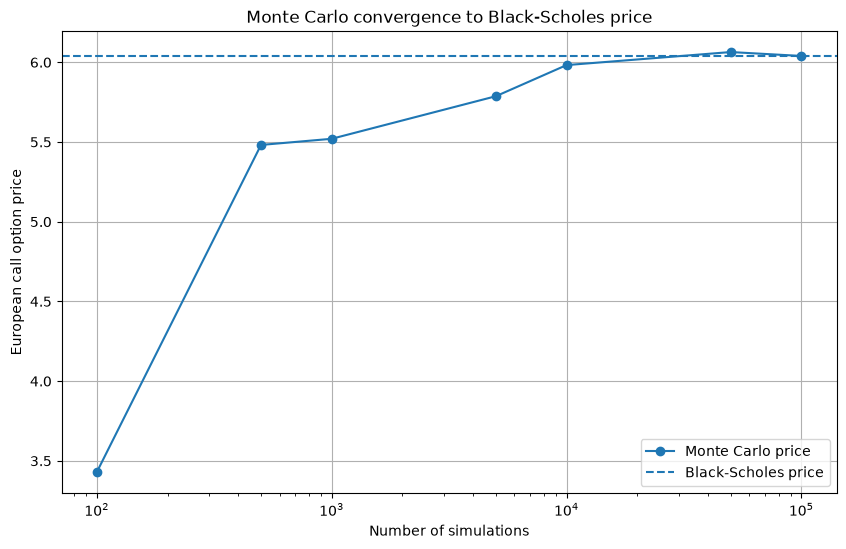

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence_df["n_paths"],
    convergence_df["mc_price"],
    marker="o",
    label="Monte Carlo price",
)

plt.axhline(
    y=bs_call_price,
    linestyle="--",
    label="Black-Scholes price",
)

plt.xscale("log")
plt.title("Monte Carlo convergence to Black-Scholes price")
plt.xlabel("Number of simulations")
plt.ylabel("European call option price")
plt.grid(True)
plt.legend()
plt.show()

## Absolute error

The absolute error measures the distance between the Monte Carlo estimate and the Black-Scholes benchmark.

The error should generally decrease as the number of simulations increases, although the curve may not be perfectly monotonic because Monte Carlo simulation is random.

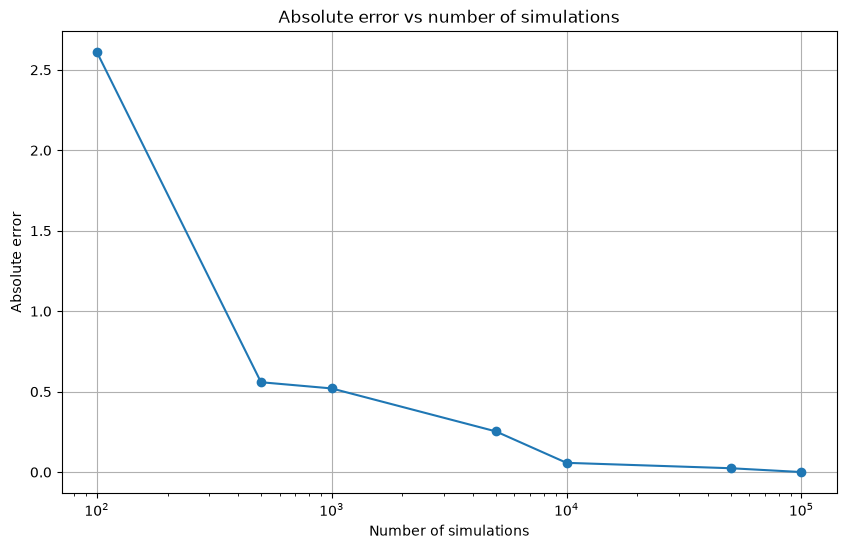

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence_df["n_paths"],
    convergence_df["absolute_error"],
    marker="o",
)

plt.xscale("log")
plt.title("Absolute error vs number of simulations")
plt.xlabel("Number of simulations")
plt.ylabel("Absolute error")
plt.grid(True)
plt.show()

## Standard error

The standard error measures the uncertainty of the Monte Carlo estimate.

A key property of Monte Carlo methods is that the error decreases approximately at rate:

\[
\frac{1}{\sqrt{N}}
\]

where `N` is the number of simulations.

This means that making the estimate 10 times more accurate requires roughly 100 times more simulations.

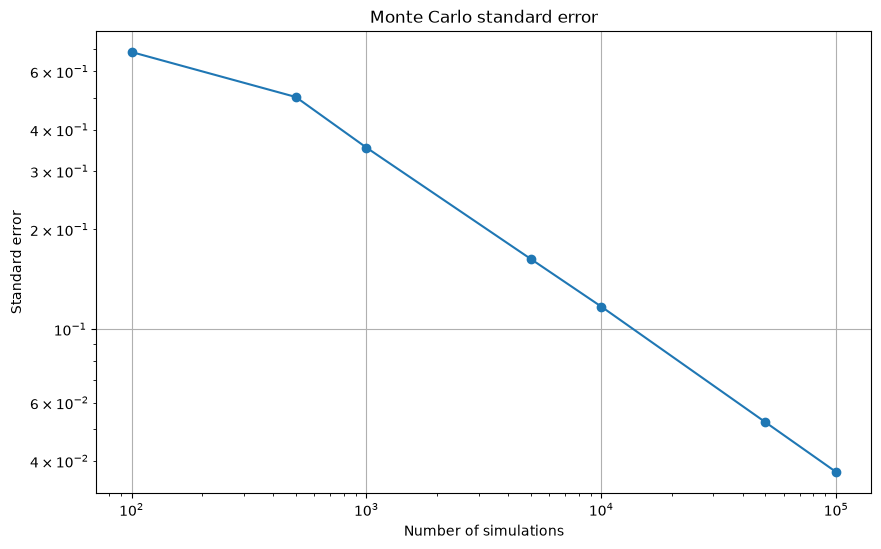

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence_df["n_paths"],
    convergence_df["standard_error"],
    marker="o",
)

plt.xscale("log")
plt.yscale("log")
plt.title("Monte Carlo standard error")
plt.xlabel("Number of simulations")
plt.ylabel("Standard error")
plt.grid(True)
plt.show()

## Interpretation

The Monte Carlo estimate becomes more stable as the number of simulations increases.

For small numbers of simulations, the estimate can be noisy. With more simulations, the standard error decreases and the price gets closer to the Black-Scholes benchmark.

This confirms the expected behaviour of Monte Carlo estimation.